# Brainstorming

We propose a genetic algorithm to optimise the cost and energy consumption of air conditioning usage based on the cost of electricity in Taipei, TW.
Because we have not in have any historical energy consumption data, energy consumption is simplified and estimated based on data found online.
We allow a buffer assuming that indoor temperature without A/C is around 2°C ~ 3°C more comfortable than outside temperature due to shade and insulation. 

 
For each hour in a day the algorithm, optimises:
- A/C settings (Temperature setting from 22°C - 27°C)
- AC Mode (ON/OFF)

Fitness function is a combination of consumed energy, cost of energy and temperature discomfort with their corresponding weights.
$$
min F(x) = \alpha * E_{cost} + \beta * E_{consumption} + \delta * temperature_{discomfort}
$$

- Energy cost: defined by cost in Taipei City
- AC Power Consumption: 2.9 kWh
$$
Eh​=2.9 kWh if mh​=1,0 if mh​=0
$$
Total:
$$
E_{total}=∑h=124Eh=2.9×∑h=124mhE_{total} = \sum_{h=1}^{24} E_h = 2.9 \times \sum_{h=1}^{24}
$$
- Temperature discomfort: penality for indoor temperature outside of 20°C ~ 27°C


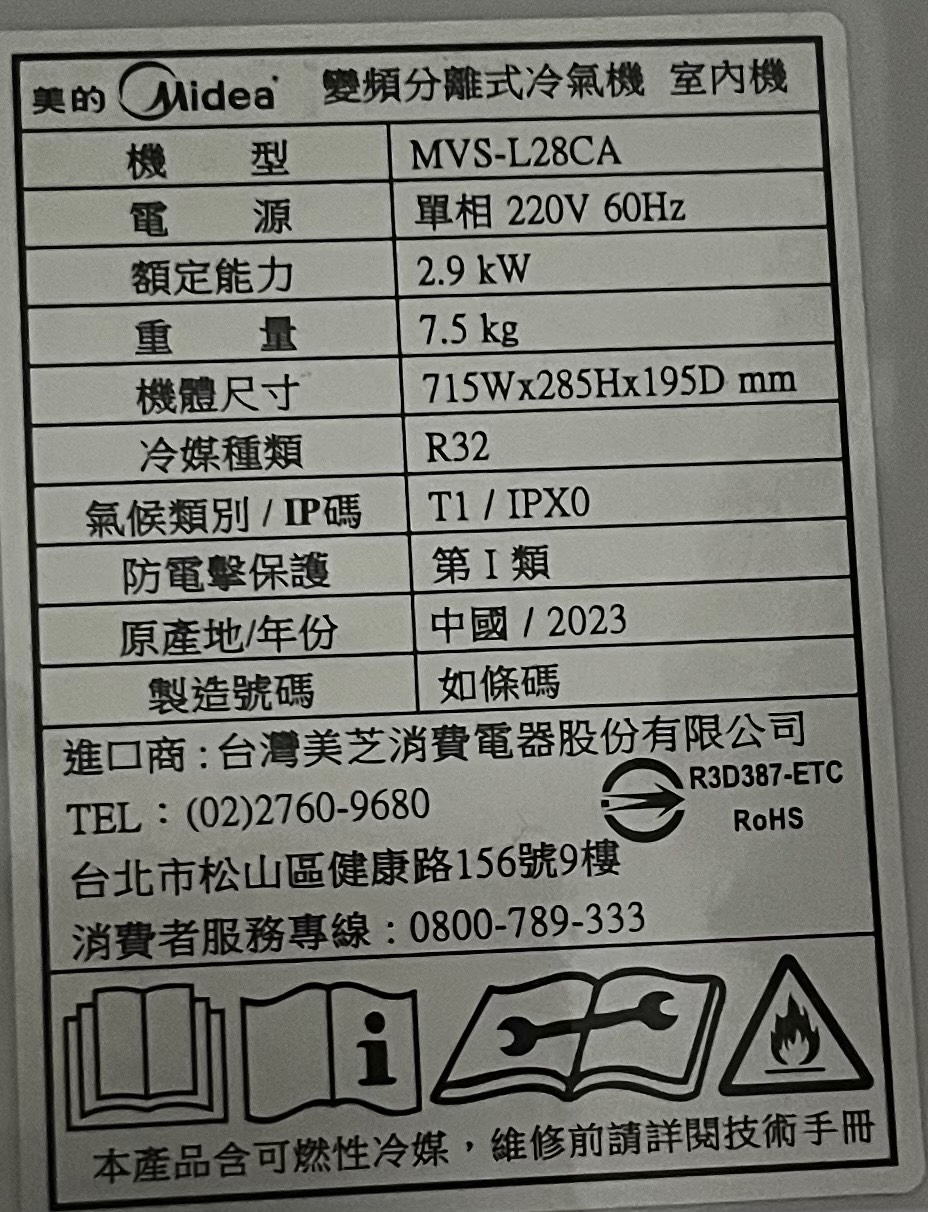

Following electricity pricing was identified for Taipei City (2026)

每月用電度數分段 | --- | 夏 月 (6 月 1 日至 9 月 30 日) | 非 夏 月 (夏月以外時間) |
| ------------|-------|------|---------|
120 度以下部分 | 每 度 | 1.78 | 1.78 |
121~330 度部分 | 每 度 | 2.55 | 2.26 |
331~500 度部分 | 每 度 | 3.80 | 3.13 |
501~700 度部分 | 每 度 | 5.14 | 4.24 |
701~1000 度部分 | 每 度 | 6.44 | 5.27 |
1001 度以上部分 | 每 度 | 8.86 | 7.03 |

$$D_h = \begin{cases}
(T_{indoor,h} - 28)^2 & \text{if } T_{indoor,h} > 28 \
(17 - T_{indoor,h})^2 & \text{if } T_{indoor,h} < 17 \
0 & \text{if } 17 \le T_{indoor,h} \le 28
\end{cases}$$

## **Complete Mathematical Formulation**

### **Decision Variables**

For each hour $h \in \{1, 2, \ldots, 24\}$:
- $m_h \in \{0, 1\}$ — A/C mode (0 = OFF, 1 = ON)
- $T_{set,h} \in [22, 27]$ — A/C temperature setpoint (continuous)

**Solution vector**: $\mathbf{x} = (m_1, T_{set,1}, m_2, T_{set,2}, \ldots, m_{24}, T_{set,24})$

**Search space dimensionality**: 48 dimensions (24 binary + 24 continuous)

---

### **Problem Parameters (Given)**

- $T_{outdoor,h}$ — Outdoor temperature at hour $h$ (°C)
- $P_{AC} = 2.9$ — A/C power consumption (kWh/hour when ON)
- $C_{comfort} = [20, 26]$ — Original comfort range (°C)
- $C_{acceptable} = [18, 28]$ — Extended acceptable range (°C)
- Electricity rate schedule: Tiered pricing for Taipei (given in your table)

---

### **Derived Variables (Calculated from Decision Variables)**

**Indoor temperature at hour h** (simplified, instant cooling):
$$T_{indoor,h} = \begin{cases}
T_{set,h} & \text{if } m_h = 1 \text{ (A/C ON)} \\
T_{outdoor,h} - 2 & \text{if } m_h = 0 \text{ (A/C OFF)}
\end{cases}$$

**Hourly energy consumption**:
$$E_h = P_{AC} \cdot m_h = \begin{cases}
2.9 & \text{if } m_h = 1 \\
0 & \text{if } m_h = 0
\end{cases} \text{ (kWh)}$$

**Total daily consumption**:
$$E_{total} = \sum_{h=1}^{24} E_h$$

**Hourly discomfort penalty** (quadratic):
$$D_h = \begin{cases}
(T_{indoor,h} - 28)^2 & \text{if } T_{indoor,h} > 28 \\
(18 - T_{indoor,h})^2 & \text{if } T_{indoor,h} < 18 \\
0 & \text{if } 18 \le T_{indoor,h} \le 28
\end{cases}$$

**Total daily discomfort**:
$$D_{total} = \sum_{h=1}^{24} D_h$$

---

### **Energy Cost Calculation (Tiered Pricing)**

Based on cumulative daily consumption $E_{total}$ (in kWh), calculate the cost using Taipei's tiered rate structure. Let $r(E)$ denote the effective cost function:

$$r(E) = \begin{cases}
1.78 \cdot E & \text{if } E \le 120 \\
1.78 \cdot 120 + 2.55 \cdot (E - 120) & \text{if } 120 < E \le 330 \\
1.78 \cdot 120 + 2.55 \cdot 210 + 3.80 \cdot (E - 330) & \text{if } 330 < E \le 500 \\
\vdots & \vdots
\end{cases}$$

(This assumes summer rates; you can extend for seasonal variation if needed.)

**Total energy cost**:
$$C_{total} = r(E_{total}) \text{ (TWD)}$$

---

### **Objective Function**

**Minimize**:
$$F(\mathbf{x}) = \alpha \cdot C_{total} + \beta \cdot E_{total} + \delta \cdot D_{total}$$

Where:
- $\alpha, \beta, \delta \in [0, 2]$ — Weight coefficients (user-specified)
- Lower values = algorithm prioritizes that objective less
- Higher values = algorithm prioritizes that objective more

**Three scenarios for comparison**:
1. **Comfort-first**: $\alpha = 0.5, \beta = 0.5, \delta = 2.0$
2. **Cost-efficient**: $\alpha = 2.0, \beta = 0.5, \delta = 0.5$
3. **Consumption-minimizing**: $\alpha = 0.5, \beta = 2.0, \delta = 0.5$

---

### **Constraints**

**Implicit constraints** (already built into decision variable domains):
1. $m_h \in \{0, 1\}$ for all $h$
2. $T_{set,h} \in [22, 27]$ for all $h$

**Optional explicit constraints** (if you want to enforce real-world rules):
- Constraint 1: No rapid A/C mode switching (e.g., avoid ON→OFF→ON in consecutive hours)
- Constraint 2: Minimum A/C runtime (e.g., if ON in hour $h$, must stay ON for at least $k$ hours)

*For now, you can omit these and add later if needed.*

---

### **Search Space Characteristics**

- **Dimensionality**: 48 (high-dimensional)
- **Variable type**: Mixed (binary + continuous)
- **Modality**: Likely multimodal (many local optima due to tiered pricing creating discontinuities)
- **Continuity**: Piecewise continuous (discrete jumps at tier boundaries)
- **Constraints**: Bounded (no inequality or equality constraints beyond variable domains)


In [1]:
from genetic_algorithm import run_optimization_scenario
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Example usage and main optimization loop
if __name__ == "__main__":
    outdoor_temps = np.array([
        22, 21, 20, 19, 19, 21, 24, 27, 30, 32, 34, 35,
        36, 35, 34, 33, 31, 29, 27, 25, 24, 23, 22, 21
    ], dtype=float)
    
    print("A/C Scheduling Optimization using Genetic Algorithm")
    print(f"Optimization problem: 48 dimensions (24 binary + 24 continuous)")
    print(f"Daily outdoor temperature profile: {outdoor_temps}\n")
    
    # Run three scenarios
    scenario1 = run_optimization_scenario(
        outdoor_temps,
        scenario_name="Comfort-First",
        weight_cost=0.5,
        weight_consumption=0.5,
        weight_discomfort=2.0,
        generations=200,
        random_seed=42
    )
    
    scenario2 = run_optimization_scenario(
        outdoor_temps,
        scenario_name="Cost-Efficient",
        weight_cost=2.0,
        weight_consumption=0.5,
        weight_discomfort=0.5,
        generations=200,
        random_seed=42
    )
    
    scenario3 = run_optimization_scenario(
        outdoor_temps,
        scenario_name="Consumption-Minimizing",
        weight_cost=0.5,
        weight_consumption=2.0,
        weight_discomfort=0.5,
        generations=200,
        random_seed=42
    )
    
    # Compare scenarios
    print(f"\n{'='*60}")
    print("SCENARIO COMPARISON")
    print(f"{'='*60}\n")
    
    scenarios = [
        ("Comfort-First", scenario1),
        ("Cost-Efficient", scenario2),
        ("Consumption-Minimizing", scenario3),
    ]
    
    print(f"{'Scenario':<20} {'Cost (TWD)':<15} {'Consumption (kWh)':<18} {'Discomfort':<15} {'A/C Hours':<12}")
    print("-" * 80)
    
    for name, results in scenarios:
        metrics = results['best_metrics']
        print(f"{name:<20} {metrics['total_cost_twd']:<15.2f} "
              f"{metrics['total_consumption_kwh']:<18.2f} "
              f"{metrics['total_discomfort']:<15.2f} "
              f"{metrics['ac_on_hours']:<12}")

A/C Scheduling Optimization using Genetic Algorithm
Optimization problem: 48 dimensions (24 binary + 24 continuous)
Daily outdoor temperature profile: [22. 21. 20. 19. 19. 21. 24. 27. 30. 32. 34. 35. 36. 35. 34. 33. 31. 29.
 27. 25. 24. 23. 22. 21.]


Running scenario: Comfort-First
Weights: Cost=0.5, Consumption=0.5, Discomfort=2.0

Generation 50/200 | Best fitness: 34.22 | Mean fitness: 86.24
Generation 100/200 | Best fitness: 34.22 | Mean fitness: 84.79
Generation 150/200 | Best fitness: 34.22 | Mean fitness: 85.96
Generation 200/200 | Best fitness: 34.22 | Mean fitness: 83.78

Optimization complete for Comfort-First
Best fitness: 34.22
Daily cost: 36.13 TWD
Daily consumption: 20.30 kWh
Daily discomfort: 3.00
A/C on hours: 7/24

Running scenario: Cost-Efficient
Weights: Cost=2.0, Consumption=0.5, Discomfort=0.5

Generation 50/200 | Best fitness: 59.32 | Mean fitness: 111.60
Generation 100/200 | Best fitness: 59.32 | Mean fitness: 107.74
Generation 150/200 | Best fitness: 59.32 | Mea